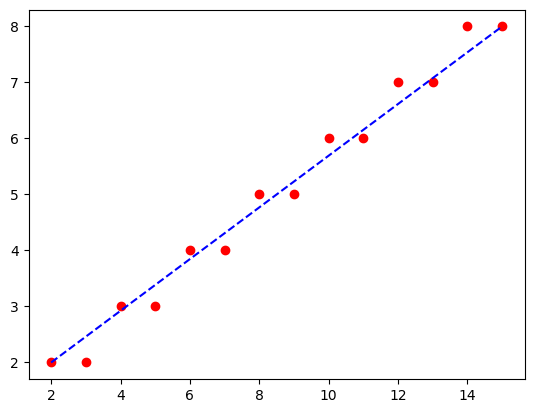

In [13]:
import matplotlib.pyplot as plt

def bresenham_line(x1, y1, x2, y2):
    points = []
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    sx = 1 if x1 < x2 else -1
    sy = 1 if y1 < y2 else -1
    err = dx - dy

    while True:
        points.append((x1, y1))
        if x1 == x2 and y1 == y2:
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x1 += sx
        if e2 < dx:
            err += dx
            y1 += sy
    return points


if __name__ == "__main__":
    x1, y1 = 2, 2
    x2, y2 = 15, 8

    points = bresenham_line(x1, y1, x2, y2)
    x, y = zip(*points)
    plt.scatter(x, y, c='red')
    plt.plot([x1, x2], [y1, y2], 'b--')
    plt.show()


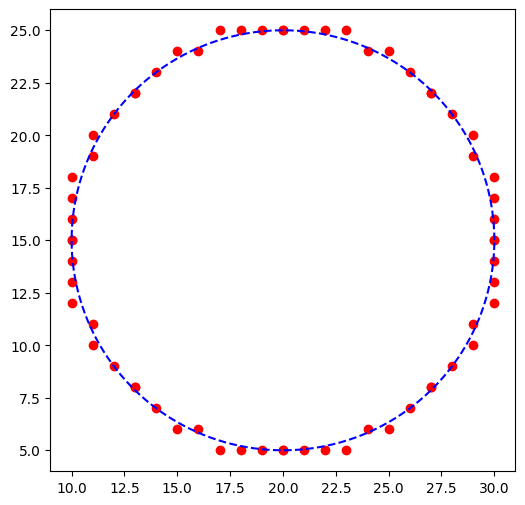

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def bresenham_circle(xc, yc, r):
    x = 0
    y = r
    d = 3 - 2 * r       # midpoint decision parameter
    points = []

    while y >= x:
        # 8-way symmetry
        points.extend([(xc + x, yc + y), (xc - x, yc + y), (xc + x, yc - y), (xc - x, yc - y),(xc + y, yc + x), (xc - y, yc + x),(xc + y, yc - x), (xc - y, yc - x)])
        if d < 0:
            d = d + 4*x + 6
        else:
            d = d + 4*(x - y) + 10
            y -= 1
        x += 1
    return points


if __name__ == "__main__":
    xc, yc, r = 20, 15, 10

    points = bresenham_circle(xc, yc, r)
    x, y = zip(*points)

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c='red')

    # For comparison: ideal circle
    theta = np.linspace(0, 2 * np.pi, 361)  # ০ থেকে ২π
    x_ideal = xc + r * np.cos(theta)
    y_ideal = yc + r * np.sin(theta)
    plt.plot(x_ideal, y_ideal, 'b--')
